# PFC: Grain Boundary Evolution

## Laplacian Operator 

The finite difference method can be adopted to express the laplacian operator $\nabla^2$ on a discrete mesh in terms of $\phi(i,j)$, i.e., $\nabla^2=\frac{\partial^2 \phi}{\partial x^2}+\frac{\partial^2 \phi}{\partial y^2}$. This can be done using a Taylor series since the neighours are on the order of $dx \sim dy \ll 1$, expanding $\phi(i,j)$ around mesh point $(i,j)$[1]:

\begin{align}
\phi(i\pm 1,j) &= \phi(i,j) \pm \frac{\partial \phi}{\partial x}dx +\frac{1}{2}\frac{\partial^2 \phi}{\partial x^2}dx^2 \\
\phi(i,j\pm 1) &= \phi(i,j) \pm \frac{\partial \phi}{\partial y}dy +\frac{1}{2}\frac{\partial^2 \phi}{\partial y^2}dy^2 \\
\phi(i\pm 1,j\pm 1) &= \phi(i,j) \pm \frac{\partial \phi}{\partial x}dx \pm \frac{\partial \phi}{\partial y}dy +\frac{1}{2}\frac{\partial^2 \phi}{\partial x^2}dx^2 +\frac{1}{2}\frac{\partial^2 \phi}{\partial y^2}dy^2
\end{align}

Sum up the 1st, 2nd, and 3rd equations:
\begin{align}
\phi(i+1,j)+\phi(i-1,j) &= 2\phi(i,j) + \frac{\partial^2 \phi}{\partial x^2}dx^2 \\
\phi(i,j+1)+\phi(i,j-1) &= 2\phi(i,j) + \frac{\partial^2 \phi}{\partial y^2}dy^2 \\
\phi(i+1,j+1)+\phi(i+1,j-1) &+ \phi(i-1,j+1)+\phi(i-1,j-1) \nonumber \\
&= 4\phi(i,j) + 2\frac{\partial^2 \phi}{\partial x^2}dx^2 + 2\frac{\partial^2 \phi}{\partial y^2}dy^2
\end{align}

$\frac{1}{2}\cdot$ 1st Eq. $+ \frac{1}{2}\cdot$ 2nd Eq. $+ \frac{1}{4}\cdot$ 3rd Eq., when $\Delta x=dx=dy$:

\begin{align}
\nabla^2\phi &= \frac{1}{\Delta x^2}\left\{\frac{1}{2}\left[\phi(i+1,j)+\phi(i-1,j) + \phi(i,j+1)+\phi(i,j-1)\right] - 3\phi(i,j)\right. \nonumber \\
&+ \left.\frac{1}{4}\left[\phi(i+1,j+1)+\phi(i+1,j-1) + \phi(i-1,j+1)+\phi(i-1,j-1)\right] \right\} \nonumber \\
&+\mathcal{O}(\Delta x^2)
\end{align}

In [1]:
import numpy as np
def laplacian(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)

A laplacian operator can be used to highlight gray level discontinuities in an image, and to deemphasize regions with slowly varying gray levels. A portrait of Laplace is adopted to show the effect of the laplacian operator:

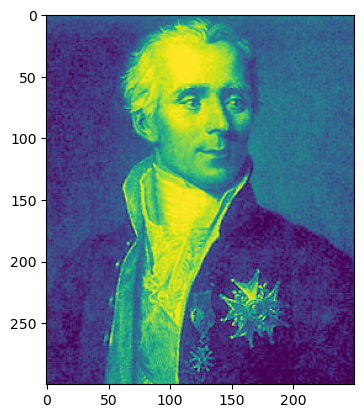

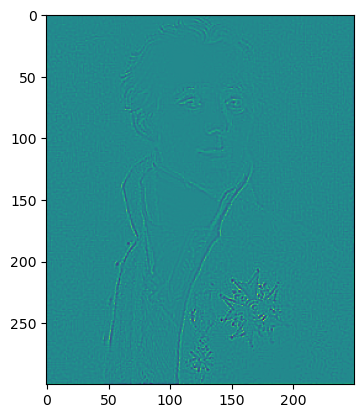

In [36]:
import matplotlib.pyplot as plt
laplace = plt.imread('../images/Laplace-Pierre-Simon.jpg')
laplace_gray = laplace.mean(axis=2)
# laplace_gray = plt.imread('../images/Einstein_tongue.jpg')
plt.figure()
plt.imshow(laplace_gray) # 载入一张拉普拉斯的黑白图片
laplace_edge = laplacian(laplace_gray, 10)
plt.figure()
plt.imshow(laplace_edge) # 突出显示图片中的边界和轮廓

## the Elastic Mismatch 

A model guarantees that when cells are brought together they deform collectively rather than shrink/grow and absorb each other:
\begin{align}
F = F_0+F_{int}
\end{align}
in which $F_0$ treats each cell as 2D soft body for which the equilibrium shape minimizes the following free energy:
\begin{align}
F_0=\sum_n\left\{\gamma_n\int_V\left[(\nabla\varphi_n)^2+\frac{30}{\lambda^2}\varphi^2(1-\varphi)^2\right]dV+\frac{\mu_n}{\pi R^2}\left(\pi R^2-\int_V\varphi^2dV\right)^2\right\}
\end{align}
while the interaction term $F_{int}$ is designed to repel each grain:
\begin{align}
F_{int}=\frac{30\kappa}{\lambda^2}\int_V\left(\sum_{n, m\neq n}\varphi_n^2\varphi_m^2\right)dV
\end{align}
where $\gamma_n$ is the parameter that controls the elasticity of the cells, $\lambda$ corresponds to the width of the boundary of any cell, $R$ the radius is the noninteracting cells tend to be circular, the energetic costs associated to change in cell area while keeping its volume approximately constant are determined by the parameter $\mu_n$, $\kappa$ is the gradient energy coefficients between cells.

The time evolution of each cell is described by:
\begin{align}
\frac{\partial \varphi_n}{\partial t} + v_n\cdot\nabla\varphi_n=-\frac{1}{2}\frac{\delta F}{\delta \varphi_n}
\end{align}
where $v_n=v_{n,I}+v_{n,A}$ can be divided into $v_{n,I}=\frac{60\kappa}{\xi\lambda^2}\int_V\left[\varphi_n(\nabla\varphi_n)\sum_{m\neq n}\varphi_m^2\right]dV$ the inactive part of the cell velocity, arising from the forces exerted on the cell by the other cells, and $v_{n,A}$ the active part (selfpropulsion) due to the internal process that require energy consumption.

Such that the time evolution of cells is described by the following two equations:

\begin{align}
\frac{\partial \varphi_n}{\partial t} &= \gamma_n\nabla^2\varphi_n-\frac{30}{\lambda^2}\left[\gamma_n\varphi_n(1-\varphi_n) + 2\kappa \sum_{m\neq n}\varphi_n\varphi_m^2\right] \nonumber \\
&- \frac{2\mu}{\pi R^2}\varphi_n\left[\int_v(\varphi_n)^2dV-\pi R^2\right] - v_n\cdot \nabla\varphi_n\\
v_n &= v_{n,A}+ \frac{60\kappa}{\xi\lambda^2}\int_V\left[\varphi_n(\nabla\varphi_n)\sum_{m\neq n}\varphi_m^2\right]dV
\end{align}

### the Gradient

To compute the $\nabla\varphi$, the [finite difference method](https://pythonnumericalmethods.berkeley.edu/notebooks/chapter23.03-Finite-Difference-Method.html) is adopted. (The gradient, as well, is associated with a matrix's "edges".)

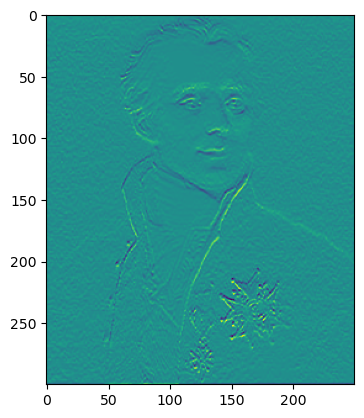

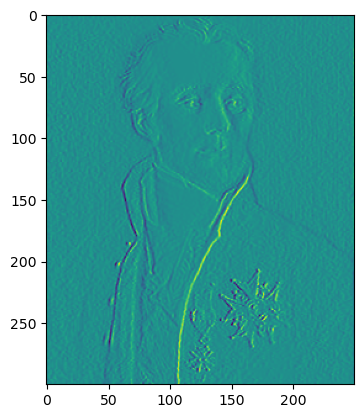

In [8]:
import numpy as np
def gradient(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    dphi_dx = (phi_ipj0 - phi_imj0) / (2 * dx)
    dphi_dy = (phi_i0jp - phi_i0jm) / (2 * dx)
    return(dphi_dx, dphi_dy)
[dphix, dphiy] = gradient(laplace_gray, 1)
plt.figure()
plt.imshow(dphix)
plt.figure()
plt.imshow(dphiy)

### the 1st term

$\gamma_n\nabla^2\varphi_n$, in the book it is on page 97.

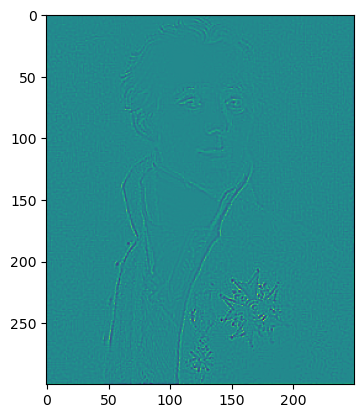

In [37]:
import numpy as np
phi_3D = np.tile(laplace_gray, [5,1,1]) # 测试用，只是想构造一个包含5个晶粒的场
def unieme(gamma, phi_all, dx):
    [ncell, nx, ny] = np.shape(phi_all)
    first = np.zeros((ncell, nx, ny))
    for n in range(ncell):
        first[n,:,:]=gamma*laplacian(phi_all[n,:,:], dx)
    return(first)
term1 = unieme(1,phi_3D,1)
plt.imshow(term1[0,:,:]) # 这与拉普拉斯edge照片是一样的

### the 2nd term 

$\left[\gamma_n\varphi_n(1-\varphi_n) + 2\kappa \sum_{m\neq n}\varphi_n\varphi_m^2\right]$, in the book it is on Page 97.

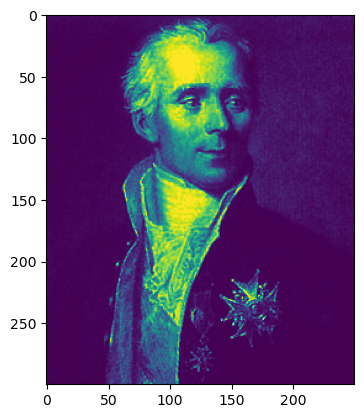

In [16]:
import numpy as np
phi_3D = np.tile(laplace_gray, [5,1,1]) # 测试用，只是想构造一个包含5个晶粒的场
def deuxieme(gamma, kappa, phi_all):
    [ncell, nx, ny] = np.shape(phi_all)
    barrier = gamma * phi_all * (1-phi_all)
    mutex = np.zeros(np.shape(phi_all))
    for n in range(ncell):
        for m in range(ncell):
            if (m != n):
                mutex[n,:,:] += phi_all[n,:,:] * phi_all[m,:,:]**2
    mutex = 2*kappa * mutex
    second = barrier + mutex
    return(second)
term2 = deuxieme(1,1,phi_3D)
plt.imshow(term2[1,:,:])

### the 3rd term

$\frac{2\mu}{\pi R^2}\varphi_n\left[\int_v(\varphi_n)^2dV-\pi R^2\right]$, in the book it is on Page 91.

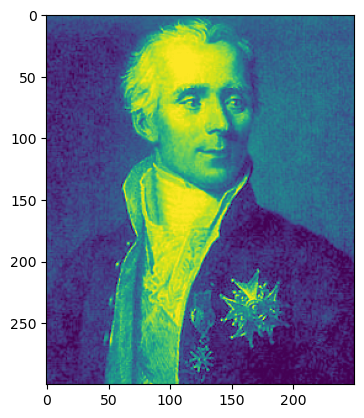

In [26]:
import numpy as np
phi_3D = np.tile(laplace_gray, [5,1,1]) # 测试用，只是想构造一个包含5个晶粒的场
def troisieme(mu, R, phi_all, dx):
    [ncell, nx, ny] = np.shape(phi_all)
    integral = np.sum(np.sum(phi_all, axis=1), axis=1) * dx**2-np.pi*R**2
    integral = integral.reshape(ncell,1,1)
    third = 2*mu / (np.pi*R**2)*phi_all*integral
    return(third)
term3 = troisieme(1,1,phi_3D, 0.1)
plt.imshow(term3[1,:,:])

## the Phase-Field Crystal Model

(Lin, before Sunday)[3]

## the Kirkendall Eq. of Motion

(HY)[4]

## Grain Boundaries and Dislocations

(HY)[5]

[1]: (page 192) NIKOLAS PROVATAS, KEN ELDER. Phase-Field Methods in Materials Science and Engineering[M/OL]. Weinheim, Germany: Wiley-VCH Verlag GmbH & Co. KGaA, 2010[2023-07-12]. http://doi.wiley.com/10.1002/9783527631520. DOI:10.1002/9783527631520.

[2]: (page 81) BINER S B. Programming Phase-Field Modeling[M/OL]. Cham: Springer International Publishing, 2017[2023-11-27]. http://link.springer.com/10.1007/978-3-319-41196-5. DOI:10.1007/978-3-319-41196-5.

[3]: (page 340) BINER S B. Programming Phase-Field Modeling[M/OL]. Cham: Springer International Publishing, 2017[2023-11-27]. http://link.springer.com/10.1007/978-3-319-41196-5. DOI:10.1007/978-3-319-41196-5.

[4]: (Eq. 3, 4) ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.

[5]: (sec. 3.3) ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.
